# Baseline models

I trained four baselines here: logistic regression, XGBoost, LightGBM, CatBoost. Each one saved its out-of-fold and test predictions to disk. The stacking, hill-climb, and pseudo-label notebooks read those back.

Everything ran on CPU. Metric was AUC. I skipped SVR, it was O(n^2) on 439k rows.

Each tree model averaged over a few seeds. I tuned LightGBM with Optuna. Three target encodings got built inside every fold.

In [1]:
VER = 1

## Load data

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

train = pd.read_parquet('data/train_features.parquet')
print('Train shape:', train.shape)
train.head(1)

Train shape: (439140, 114)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,stintprog_x_ponestop,tyrelife_pct_in_compound,tyrelife_pct_in_stint,tyrelife_pct_in_race_compound,laptime_pct_in_compound,position_pct_in_race,cumdeg_pct_in_stint,raceprogress_decile,tyrelife_decile_in_compound,position_bucket3
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,...,0.335502,0.956276,0.955311,0.955266,0.147495,0.335186,0.8,7,9,1


In [3]:
test = pd.read_parquet('data/test_features.parquet')
print('Test shape:', test.shape)
test.head(1)

Test shape: (188165, 113)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,stintprog_x_ponestop,tyrelife_pct_in_compound,tyrelife_pct_in_stint,tyrelife_pct_in_race_compound,laptime_pct_in_compound,position_pct_in_race,cumdeg_pct_in_stint,raceprogress_decile,tyrelife_decile_in_compound,position_bucket3
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,...,0.191136,0.860569,0.868403,0.759843,0.559999,0.234545,0.65,3,8,0


In [4]:
TARGET = 'PitNextLap'

# Auto-detect features: everything except id, target, and the raw categoricals used only for TE.
# 'Race' stays in the tree feature set (handled natively); the linear model drops it.
DROP = ['id', TARGET, 'Driver', 'Compound']
FEATURES_TREE   = [c for c in train.columns if c not in DROP]
FEATURES_LINEAR = [c for c in FEATURES_TREE if c != 'Race']
TE_COLS = ['driver_pit_rate', 'driver_compound_pit_rate', 'race_compound_pit_rate']
print(f'tree features:   {len(FEATURES_TREE)}  (+{len(TE_COLS)} per-fold TEs)')
print(f'linear features: {len(FEATURES_LINEAR)}  (+{len(TE_COLS)} per-fold TEs)')

tree features:   110  (+3 per-fold TEs)
linear features: 109  (+3 per-fold TEs)


## Cross-validation setup

10-fold StratifiedGroupKFold grouped by Race and Year. fold_rates builds the three target-encoding tables from the training fold only. add_te maps them onto any split.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 10
RANDOM_STATE = 42
y = train[TARGET].astype(int).values
groups = train.groupby(['Race', 'Year']).ngroup().values
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def fold_rates(tr):
    s = pd.Series(y[tr])
    gmean = s.mean()
    drv = s.groupby(train['Driver'].iloc[tr].values).mean()
    dc  = s.groupby([train['Driver'].iloc[tr].values, train['Compound'].iloc[tr].values]).mean()
    rc  = s.groupby([train['Race'].iloc[tr].values, train['Compound'].iloc[tr].values]).mean()
    return gmean, drv, dc, rc

def add_te(base_df, src_df, rates):
    gmean, drv, dc, rc = rates
    out = base_df.copy()
    out['driver_pit_rate'] = src_df['Driver'].map(drv).fillna(gmean).values
    out['driver_compound_pit_rate'] = dc.reindex(
        pd.MultiIndex.from_arrays([src_df['Driver'], src_df['Compound']])).fillna(gmean).values
    out['race_compound_pit_rate'] = rc.reindex(
        pd.MultiIndex.from_arrays([src_df['Race'], src_df['Compound']])).fillna(gmean).values
    return out

## Constant model

Predicts the mean target for everyone. On AUC a constant sits at 0.5. That is the floor every other model has to beat.

In [6]:
p = train[TARGET].mean()
print(f'Train pit rate = {p:.5f}')
print('Constant Model Baseline:')
print(' => OOF AUC = 0.50000 (all predictions tied)')

Train pit rate = 0.19898
Constant Model Baseline:
 => OOF AUC = 0.50000 (all predictions tied)


## Logistic regression

Linear baseline on standardized numeric features plus the three per-fold target encodings. Race is dropped. I filled NaNs with train-fold means before scaling.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

oof_linear  = np.zeros(len(train))
pred_linear = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(train, y, groups)):
    rates = fold_rates(tr)
    X_tr = add_te(train[FEATURES_LINEAR].iloc[tr], train.iloc[tr], rates)
    X_va = add_te(train[FEATURES_LINEAR].iloc[va], train.iloc[va], rates)
    X_te = add_te(test[FEATURES_LINEAR],           test,           rates)

    fill = X_tr.mean()
    X_tr, X_va, X_te = X_tr.fillna(fill), X_va.fillna(fill), X_te.fillna(fill)

    scaler = StandardScaler()
    Xs_tr = scaler.fit_transform(X_tr)
    Xs_va = scaler.transform(X_va)
    Xs_te = scaler.transform(X_te)

    model = LogisticRegression(C=1.0, max_iter=2000)
    model.fit(Xs_tr, y[tr])
    oof_linear[va]    = model.predict_proba(Xs_va)[:, 1]
    pred_linear[fold] = model.predict_proba(Xs_te)[:, 1]
    print(f'Fold {fold+1} AUC: {roc_auc_score(y[va], oof_linear[va]):.5f}')

print('-' * 40)
print(f'Linear Model, CV OOF AUC: {roc_auc_score(y, oof_linear):.5f}')

Fold 1 AUC: 0.91687


Fold 2 AUC: 0.88689


Fold 3 AUC: 0.89187


Fold 4 AUC: 0.86790


Fold 5 AUC: 0.85557


...

Fold 7 AUC: 0.87704


Fold 8 AUC: 0.89809


Fold 9 AUC: 0.86198


Fold 10 AUC: 0.89028
----------------------------------------


Linear Model, CV OOF AUC: 0.87888


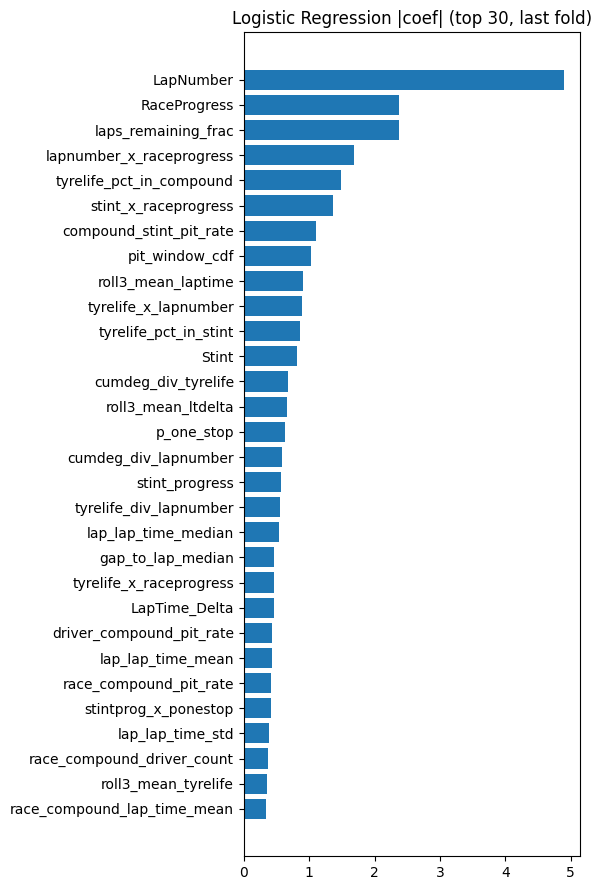

In [8]:
importance = np.abs(model.coef_[0])
names = FEATURES_LINEAR + TE_COLS
imp_df = pd.DataFrame({'feature': names, 'importance': importance}).sort_values('importance', ascending=False)
plt.figure(figsize=(6, 9))
plt.barh(imp_df['feature'].head(30), imp_df['importance'].head(30))
plt.gca().invert_yaxis()
plt.title('Logistic Regression |coef| (top 30, last fold)')
plt.tight_layout()
plt.show()

In [9]:
np.save(f'data/train_oof_linear_v{VER}.npy', oof_linear)
np.save(f'data/test_pred_linear_v{VER}.npy', pred_linear)

## SVR, skipped

Polynomial-kernel SVR is O(n^2) in the kernel matrix. At 439k rows on CPU that is hours per fold. The three tree models cover non-linearity anyway.

## Tree feature matrix

Shared by XGBoost, LightGBM, CatBoost. Race is set to a pandas category.

In [10]:
X      = train[FEATURES_TREE].copy()
X_test = test[FEATURES_TREE].copy()
X['Race']      = X['Race'].astype('category')
X_test['Race'] = pd.Categorical(X_test['Race'], categories=X['Race'].cat.categories)

## XGBoost

Non-linear baseline. Native categorical support, 3-seed averaging per fold.

In [11]:
from xgboost import XGBClassifier

SEEDS_XGB = [42, 17, 2024]
xgb_params = dict(
    n_estimators=2000, max_depth=6, learning_rate=0.05, min_child_weight=10,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', enable_categorical=True, eval_metric='auc',
    early_stopping_rounds=100, verbosity=0,
)

oof_xgb  = np.zeros(len(train))
pred_xgb = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
    rates = fold_rates(tr)
    X_tr = add_te(X.iloc[tr], train.iloc[tr], rates)
    X_va = add_te(X.iloc[va], train.iloc[va], rates)
    X_te = add_te(X_test,      test,           rates)
    fva = np.zeros(len(va)); fte = np.zeros(len(test))
    for seed in SEEDS_XGB:
        m = XGBClassifier(**xgb_params, random_state=seed)
        m.fit(X_tr, y[tr], eval_set=[(X_va, y[va])], verbose=False)
        fva += m.predict_proba(X_va)[:, 1] / len(SEEDS_XGB)
        fte += m.predict_proba(X_te)[:, 1] / len(SEEDS_XGB)
    oof_xgb[va]    = fva
    pred_xgb[fold] = fte
    print(f'Fold {fold+1} AUC: {roc_auc_score(y[va], fva):.5f}')

print('-' * 40)
print(f'XGB Model, CV OOF AUC: {roc_auc_score(y, oof_xgb):.5f}')

Fold 1 AUC: 0.94578


Fold 2 AUC: 0.92169


Fold 3 AUC: 0.93515


Fold 4 AUC: 0.90942


Fold 5 AUC: 0.94020


...

Fold 7 AUC: 0.92656


Fold 8 AUC: 0.92058


Fold 9 AUC: 0.92488


Fold 10 AUC: 0.94964
----------------------------------------


XGB Model, CV OOF AUC: 0.92424


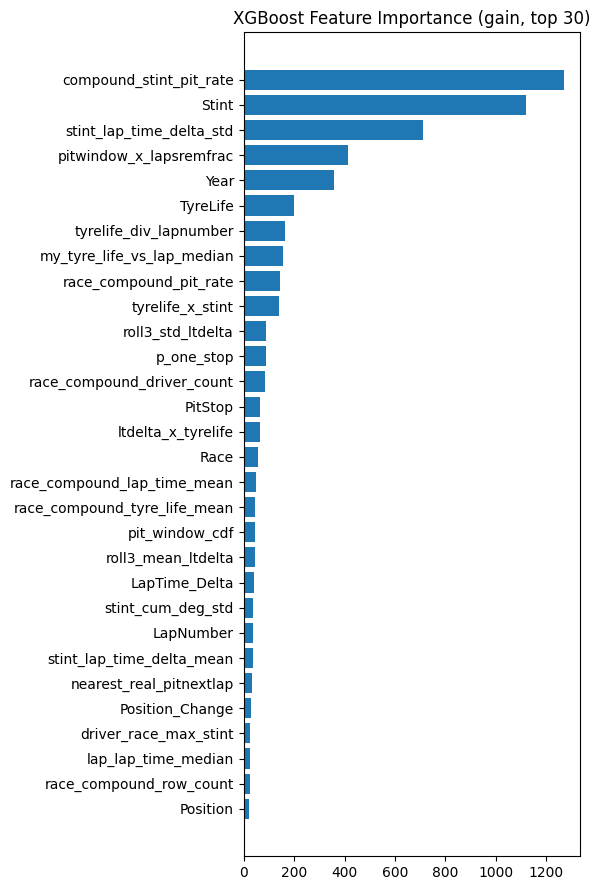

In [12]:
score = m.get_booster().get_score(importance_type='gain')
imp = pd.DataFrame({'feature': list(score.keys()), 'importance': list(score.values())})\
        .sort_values('importance', ascending=False)
plt.figure(figsize=(6, 9))
plt.barh(imp['feature'].head(30), imp['importance'].head(30))
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (gain, top 30)')
plt.tight_layout()
plt.show()

In [13]:
np.save(f'data/train_oof_xgb_v{VER}.npy', oof_xgb)
np.save(f'data/test_pred_xgb_v{VER}.npy', pred_xgb)

## LightGBM tuning with Optuna

50 trials on the first fold, which is fast. The best params feed the LightGBM CV below. Trial progress prints through Optuna's INFO logging.

In [14]:
import optuna
import lightgbm as lgb

tr0, va0 = next(iter(cv.split(X, y, groups)))
rates0 = fold_rates(tr0)
X0_tr = add_te(X.iloc[tr0], train.iloc[tr0], rates0)
X0_va = add_te(X.iloc[va0], train.iloc[va0], rates0)

def objective(trial):
    params = {
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'bagging_freq': 5, 'random_state': 42, 'verbose': -1,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X0_tr, y[tr0], eval_set=[(X0_va, y[va0])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return roc_auc_score(y[va0], m.predict_proba(X0_va)[:, 1])

optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=False)
best_params = {**study.best_params, 'n_estimators': 2000, 'bagging_freq': 5, 'random_state': 42, 'verbose': -1}
print(f'best tuning AUC: {study.best_value:.5f}')
print(f'best params: {best_params}')

C:\Users\yoavi\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[I 2026-06-03 17:14:16,976] A new study created in memory with name: no-name-617996ad-6ecd-411f-9870-6737cab8df3c


[I 2026-06-03 17:15:06,913] Trial 0 finished with value: 0.945065135061336 and parameters: {'learning_rate': 0.0793942977566087, 'num_leaves': 91, 'min_child_samples': 165, 'feature_fraction': 0.7351487630177531, 'bagging_fraction': 0.6160391491951351, 'reg_alpha': 4.634722077265611, 'reg_lambda': 0.06280378498938412}. Best is trial 0 with value: 0.945065135061336.


[I 2026-06-03 17:15:30,295] Trial 1 finished with value: 0.9457597646315483 and parameters: {'learning_rate': 0.08744707431085658, 'num_leaves': 177, 'min_child_samples': 110, 'feature_fraction': 0.6219830387147058, 'bagging_fraction': 0.7547292930899698, 'reg_alpha': 0.03802906181329684, 'reg_lambda': 0.3807769665231173}. Best is trial 1 with value: 0.9457597646315483.


[I 2026-06-03 17:16:35,999] Trial 2 finished with value: 0.9472896449899086 and parameters: {'learning_rate': 0.034973387661352114, 'num_leaves': 165, 'min_child_samples': 169, 'feature_fraction': 0.5271839716847786, 'bagging_fraction': 0.698320589776604, 'reg_alpha': 0.0019370564207562056, 'reg_lambda': 9.034861974308814}. Best is trial 2 with value: 0.9472896449899086.


...

[I 2026-06-03 18:03:43,240] Trial 46 finished with value: 0.9461178634136195 and parameters: {'learning_rate': 0.06905483854445618, 'num_leaves': 225, 'min_child_samples': 92, 'feature_fraction': 0.40914402594857713, 'bagging_fraction': 0.8398457780646685, 'reg_alpha': 0.0016682403854063421, 'reg_lambda': 0.051554499322681115}. Best is trial 22 with value: 0.9474226517073069.


[I 2026-06-03 18:04:03,478] Trial 47 finished with value: 0.9458570431172477 and parameters: {'learning_rate': 0.08068440137028807, 'num_leaves': 16, 'min_child_samples': 150, 'feature_fraction': 0.6392878346001734, 'bagging_fraction': 0.7033345184371974, 'reg_alpha': 0.0060097853356268095, 'reg_lambda': 0.005673395068684018}. Best is trial 22 with value: 0.9474226517073069.


[I 2026-06-03 18:05:02,324] Trial 48 finished with value: 0.9466701652487485 and parameters: {'learning_rate': 0.016368855163626152, 'num_leaves': 67, 'min_child_samples': 137, 'feature_fraction': 0.48833171214159027, 'bagging_fraction': 0.677421148109637, 'reg_alpha': 0.10779863281311905, 'reg_lambda': 0.003137137743572294}. Best is trial 22 with value: 0.9474226517073069.


[I 2026-06-03 18:06:03,434] Trial 49 finished with value: 0.9468080777649283 and parameters: {'learning_rate': 0.025879378875804788, 'num_leaves': 248, 'min_child_samples': 173, 'feature_fraction': 0.4471082498283021, 'bagging_fraction': 0.7568987660878878, 'reg_alpha': 0.004875906978321345, 'reg_lambda': 0.016890181965784234}. Best is trial 22 with value: 0.9474226517073069.


best tuning AUC: 0.94742
best params: {'learning_rate': 0.013357819100654459, 'num_leaves': 246, 'min_child_samples': 157, 'feature_fraction': 0.49067358114335813, 'bagging_fraction': 0.7106131839120189, 'reg_alpha': 0.0026231864880153295, 'reg_lambda': 0.001667920162991998, 'n_estimators': 2000, 'bagging_freq': 5, 'random_state': 42, 'verbose': -1}


## LightGBM

Optuna-tuned params, 5-seed averaging.

In [15]:
SEEDS_LGB = [42, 17, 2024, 1337, 9999]
oof_lgb  = np.zeros(len(train))
pred_lgb = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
    rates = fold_rates(tr)
    X_tr = add_te(X.iloc[tr], train.iloc[tr], rates)
    X_va = add_te(X.iloc[va], train.iloc[va], rates)
    X_te = add_te(X_test,      test,           rates)
    fva = np.zeros(len(va)); fte = np.zeros(len(test))
    for seed in SEEDS_LGB:
        m = lgb.LGBMClassifier(**{**best_params, 'random_state': seed})
        m.fit(X_tr, y[tr], eval_set=[(X_va, y[va])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
        fva += m.predict_proba(X_va)[:, 1] / len(SEEDS_LGB)
        fte += m.predict_proba(X_te)[:, 1] / len(SEEDS_LGB)
    oof_lgb[va]    = fva
    pred_lgb[fold] = fte
    print(f'Fold {fold+1} AUC: {roc_auc_score(y[va], fva):.5f}')

print('-' * 40)
print(f'LightGBM, CV OOF AUC: {roc_auc_score(y, oof_lgb):.5f}')

Fold 1 AUC: 0.94787


Fold 2 AUC: 0.92463


Fold 3 AUC: 0.93579


Fold 4 AUC: 0.90988


Fold 5 AUC: 0.94050


...

Fold 7 AUC: 0.92650


Fold 8 AUC: 0.92432


Fold 9 AUC: 0.93300


Fold 10 AUC: 0.95036
----------------------------------------


LightGBM, CV OOF AUC: 0.93033


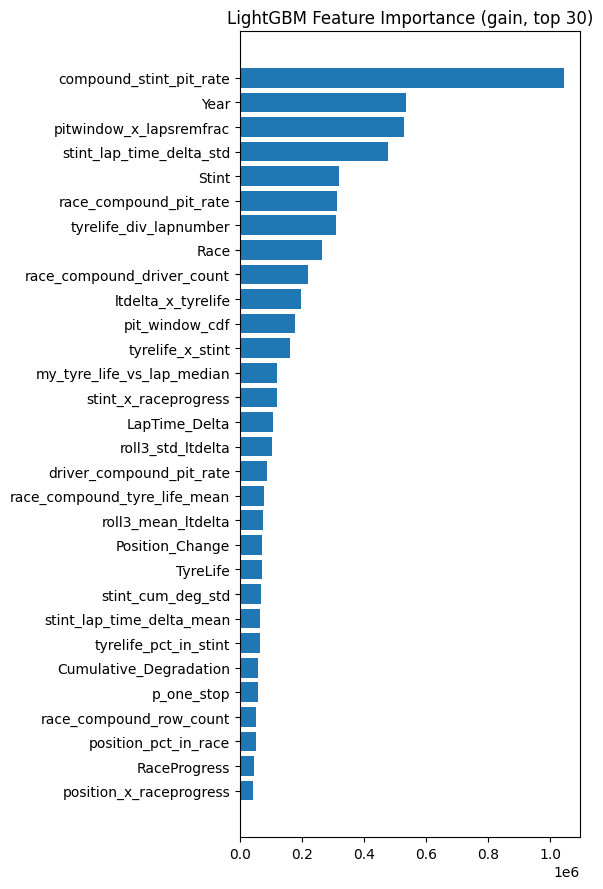

In [16]:
imp = pd.DataFrame({'feature': X_tr.columns,
                    'importance': m.booster_.feature_importance(importance_type='gain')})\
        .sort_values('importance', ascending=False)
plt.figure(figsize=(6, 9))
plt.barh(imp['feature'].head(30), imp['importance'].head(30))
plt.gca().invert_yaxis()
plt.title('LightGBM Feature Importance (gain, top 30)')
plt.tight_layout()
plt.show()

In [17]:
np.save(f'data/train_oof_lgb_v{VER}.npy', oof_lgb)
np.save(f'data/test_pred_lgb_v{VER}.npy', pred_lgb)

## CatBoost

Ordered target encoding on Race. Its errors come out decorrelated from XGB and LGB, which helps the blend later. Single seed since CatBoost is slow. Race is cast to string per fold.

In [18]:
import catboost as cb

cb_params = dict(
    iterations=2000, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE, early_stopping_rounds=100, eval_metric='AUC',
    cat_features=['Race'], verbose=500, use_best_model=True,
)

oof_cb  = np.zeros(len(train))
pred_cb = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
    rates = fold_rates(tr)
    X_tr = add_te(X.iloc[tr], train.iloc[tr], rates)
    X_va = add_te(X.iloc[va], train.iloc[va], rates)
    X_te = add_te(X_test,      test,           rates)
    for D in (X_tr, X_va, X_te):
        D['Race'] = D['Race'].astype(str)
    m = cb.CatBoostClassifier(**cb_params)
    m.fit(X_tr, y[tr], eval_set=(X_va, y[va]))
    oof_cb[va]    = m.predict_proba(X_va)[:, 1]
    pred_cb[fold] = m.predict_proba(X_te)[:, 1]
    print(f'Fold {fold+1} AUC: {roc_auc_score(y[va], oof_cb[va]):.5f}  best_iter={m.best_iteration_}')

print('-' * 40)
print(f'CatBoost, CV OOF AUC: {roc_auc_score(y, oof_cb):.5f}')

0:	test: 0.9210805	best: 0.9210805 (0)	total: 523ms	remaining: 17m 25s


500:	test: 0.9423209	best: 0.9423209 (500)	total: 2m 27s	remaining: 7m 21s


1000:	test: 0.9439298	best: 0.9439436 (942)	total: 4m 54s	remaining: 4m 54s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9441719258
bestIteration = 1244

Shrink model to first 1245 iterations.


Fold 1 AUC: 0.94417  best_iter=1244


...

500:	test: 0.9469927	best: 0.9470179 (495)	total: 2m 33s	remaining: 7m 38s


1000:	test: 0.9479867	best: 0.9480357 (929)	total: 5m 3s	remaining: 5m 2s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9480356855
bestIteration = 929

Shrink model to first 930 iterations.


Fold 10 AUC: 0.94804  best_iter=929
----------------------------------------


CatBoost, CV OOF AUC: 0.93186


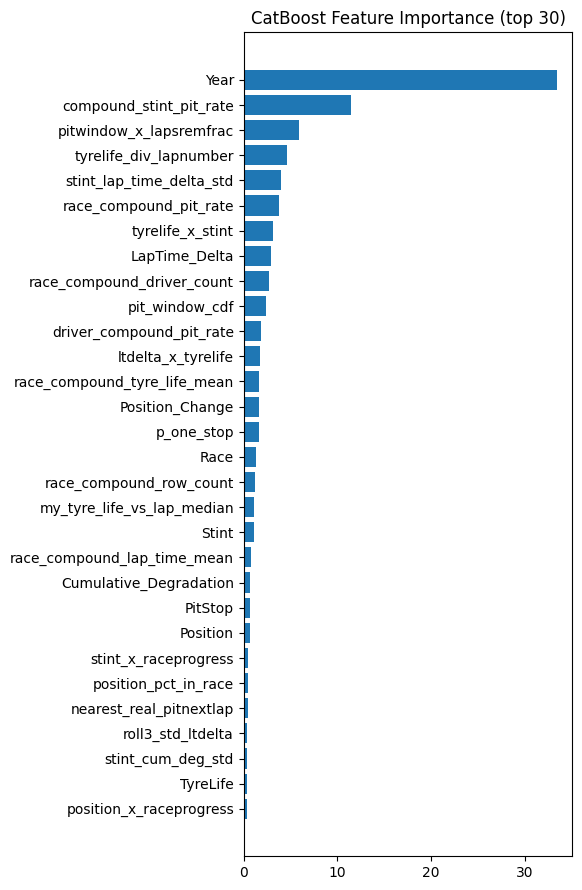

In [19]:
imp = pd.DataFrame({'feature': X_tr.columns, 'importance': m.get_feature_importance()})\
        .sort_values('importance', ascending=False)
plt.figure(figsize=(6, 9))
plt.barh(imp['feature'].head(30), imp['importance'].head(30))
plt.gca().invert_yaxis()
plt.title('CatBoost Feature Importance (top 30)')
plt.tight_layout()
plt.show()

In [20]:
np.save(f'data/train_oof_cb_v{VER}.npy', oof_cb)
np.save(f'data/test_pred_cb_v{VER}.npy', pred_cb)

## Summary

OOF AUC by model. The saved arrays feed the stacking, hill-climb, and pseudo-label notebooks.

In [21]:
results = {
    'Constant': 0.5,
    'Linear':   roc_auc_score(y, oof_linear),
    'XGBoost':  roc_auc_score(y, oof_xgb),
    'LightGBM': roc_auc_score(y, oof_lgb),
    'CatBoost': roc_auc_score(y, oof_cb),
}
summary = pd.DataFrame({'OOF AUC': results}).sort_values('OOF AUC', ascending=False)
print(summary.to_string())

           OOF AUC
CatBoost  0.931858
LightGBM  0.930335
XGBoost   0.924240
Linear    0.878878
Constant  0.500000
